In [15]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, os, json

pd.set_option('display.max_columns', None)

In [16]:
OPTIONS = json.loads(open('info.json', 'r', encoding='utf-8').read()).get('target')
OPTIONS

{'test': 5, 'axis': 'z'}

In [17]:
axis = OPTIONS.get('axis')
target_axis = ['roll', 'wx', 'az'] if axis == 'z' else ['pitch', 'wz', 'ax']
print(target_axis)

['roll', 'wx', 'az']


# DADOS

In [18]:
df = pd.read_csv('Format/files/output.csv')
df

,time,target_wz,target_tmp,target_pitch,target_e,target_ay,target_ax,target_wx,target_wy,target_az,target_roll,target_yaw,static,ref_sample_time,ref_wz,ref_pitch,ref_q0,ref_q1,ref_ay,ref_wx,ref_ax,ref_q2,ref_wy,ref_la_pos_mon_d,ref_az,ref_roll,ref_yaw,ref_q3
0,0.0,-6.92455,53.0,-1.525,-22.176,10.733555,0.194623,-47.92960,-1.16726,-0.614769,18.043,2.936,False,605000000.0,0.200478,0.304871,-0.8118,0.5835,9.590,-44.581846,0.06400,0.01196,0.471315,-0.5252,0.8262,-71.390541,2.771970,-0.02120
1,0.1,-8.13221,52.9,-0.742,-16.704,11.618576,0.294719,-58.13591,-1.05996,-0.532550,12.732,2.725,False,705000000.0,0.165413,0.337243,-0.7843,0.6199,10.540,-54.981030,0.09128,0.01243,0.546086,-0.4685,0.8149,-76.661753,2.723841,-0.02047
2,0.2,-8.42212,53.1,0.119,-10.440,12.899422,0.256924,-67.53252,-1.95110,-2.312996,6.586,2.578,False,805000000.0,0.189592,0.366750,-0.7505,0.6604,11.460,-62.337808,0.12330,0.01297,0.585563,-0.4231,0.7793,-82.677810,2.667691,-0.01959
3,0.3,-9.92099,53.3,1.010,-3.240,12.406766,0.425020,-67.39252,-1.05936,-0.455019,-0.016,2.655,False,905000000.0,0.310085,0.387721,-0.7116,0.7021,12.170,-66.291217,0.19090,0.01440,-1.635795,-0.3990,0.7029,-89.209529,2.743322,-0.01942
4,0.4,-9.44709,52.9,1.984,3.744,12.362390,0.271203,-66.62502,-1.97845,-0.208931,-6.779,2.656,False,5000000.0,0.653172,0.442381,-0.6696,0.7424,12.510,-66.806879,0.17590,0.01442,0.789536,-0.4016,0.5932,-95.913135,2.624720,-0.01821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2345,234.5,-0.00493,55.6,1.368,-1.692,9.717615,0.235938,-0.09929,-0.03678,-0.402014,-2.509,5.289,True,105000000.0,0.024133,1.645535,-0.6920,0.7197,9.783,-0.015711,0.11520,0.03009,-0.020449,-1.3240,0.3695,-92.131613,6.371291,-0.04888
2346,234.6,0.50338,55.4,1.367,-1.692,9.768983,0.257170,-0.18597,0.40111,-0.404622,-2.506,5.291,True,205000000.0,-0.022162,1.644962,-0.6920,0.7197,9.778,0.006503,0.11290,0.03010,-0.020529,-1.3240,0.3681,-92.131613,6.371291,-0.04888
2347,234.7,0.14588,55.6,1.367,-1.692,9.796167,0.266545,0.06592,-0.14609,-0.485586,-2.506,5.289,True,305000000.0,0.007128,1.645535,-0.6920,0.7197,9.783,-0.008749,0.11420,0.03010,-0.002209,-1.3230,0.3692,-92.131613,6.377020,-0.04889
2348,234.8,0.04660,55.5,1.367,-1.692,9.755871,0.222170,-0.01801,-0.00522,-0.409330,-2.504,5.290,True,405000000.0,-0.020953,1.644962,-0.6920,0.7196,9.779,0.017951,0.11310,0.03012,-0.044284,-1.3230,0.3684,-92.131613,6.377020,-0.04890


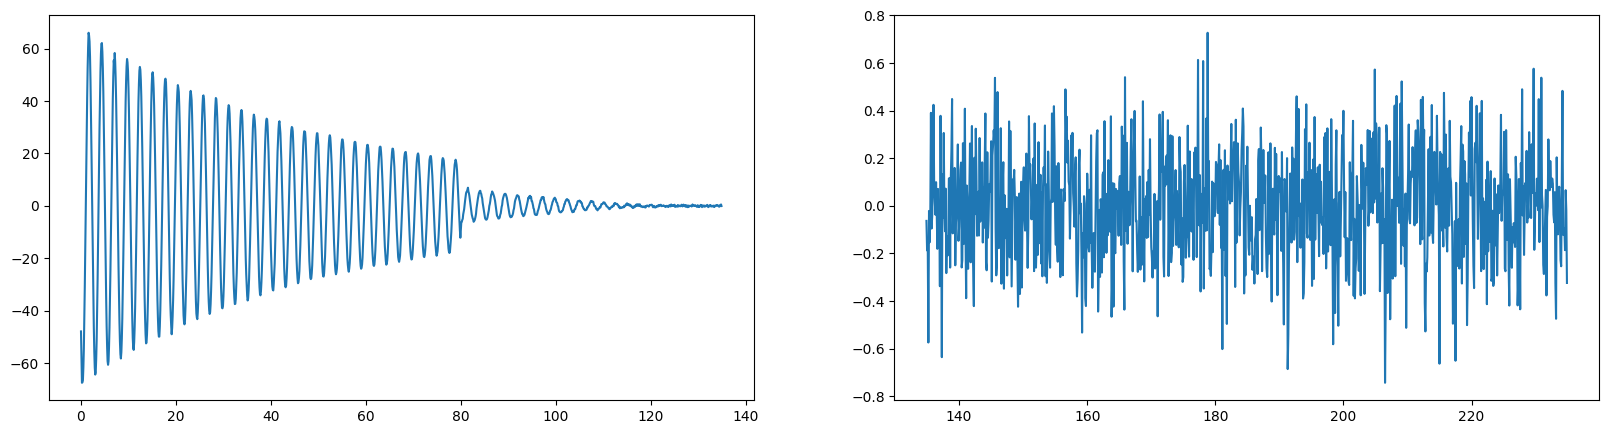

In [19]:
df_static  = df.loc[df.static]
df_dynamic = df.loc[~df.static]
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1); plt.plot(df_dynamic.time, df_dynamic.target_wx)
plt.subplot(1, 2, 2); plt.plot(df_static.time, df_static.target_wx)

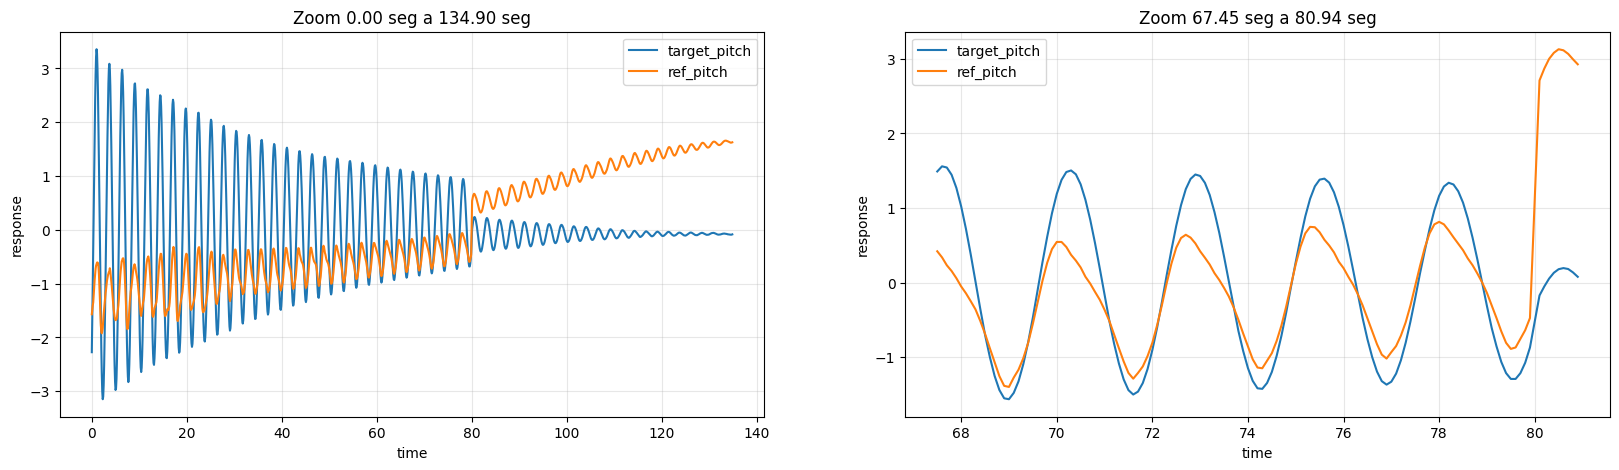

In [20]:
def normalize(array):
    return (array - np.mean(array)) / np.std(array)

def plotViews(df, varname, limits=(0, 1), norm=True):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    values1 = target['target_' + varname] if not norm else normalize(target['target_' + varname])
    values2 = target['ref_' + varname] if not norm else normalize(target['ref_' + varname])

    plt.plot(target.time, values1, label='target_' + varname)
    plt.plot(target.time, values2, label='ref_' + varname)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1); plotViews(df_dynamic, 'pitch', limits=(0, 1))
plt.subplot(1, 2, 2); plotViews(df_dynamic,  'pitch', limits=(0.5, 0.6))

# DEFASAGEM

In [21]:
class Phaser:
    def __init__(self, target, reference):
        self.target    = target
        self.reference = reference

    def get(self, df):
        x_norm = normalize(df[self.target])
        y_norm = normalize(df[self.reference])
        
        correlation = np.correlate(y_norm, x_norm, mode='full')
        lags = np.arange(-len(df) + 1, len(df))
        lag  = lags[np.argmax(correlation)]
        return lag

    def set(self, df, lag):
        if abs(lag) < 2:
            return df

        df.loc[:, self.target] = df[self.target].shift(lag)
        df = df.dropna().reset_index(drop=True)
        return df


phaser = Phaser('target_pitch', 'ref_pitch')
lag    = phaser.get(df_dynamic)

df_dynamic = phaser.set(df_dynamic, lag)
df_static  = phaser.set(df_static, lag)
print('System LAG:', lag, 'samples')

System LAG: 0 samples


# MODELO DE CALIBRAÇÃO

In [22]:
from scipy.optimize import curve_fit, OptimizeWarning
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=OptimizeWarning)

In [23]:
class LinearFit:
    def __init__(self, df, variables, time_col='time', fuse=False):
        self.time = np.array(df[time_col])
        self.variables = variables
        self.fuse = fuse
        
        self.X = np.column_stack([df[f'target_{var}'] for var in variables])
        self.Y = np.column_stack([df[f'ref_{var}']    for var in variables])
        
        self.M = np.eye(3)
        self.B = np.zeros(3)

        self.Y_model = np.zeros_like(self.Y)
        self.errors  = np.zeros_like(self.Y)
        self.metrics = {}

    def update(self):
        N = self.X.shape[0]
        
        if not self.fuse: # y = ax + b
            self.M = np.zeros((len(self.variables), len(self.variables)))
            self.B = np.zeros(len(self.variables))
            
            for i in range(len(self.variables)):
                x_single = self.X[:, i].reshape(-1, 1)
                X_aug    = np.hstack((x_single, np.ones((N, 1))))
                w, _, _, _ = np.linalg.lstsq(X_aug, self.Y[:, i], rcond=None)
                
                self.M[i, i] = w[0]  # Scale
                self.B[i]    = w[1]  # Bias
                self.Y_model[:, i] = X_aug @ w
                
        else: # Fusão ativada
            X_aug = np.hstack((self.X, np.ones((N, 1))))
            W, _, _, _ = np.linalg.lstsq(X_aug, self.Y, rcond=None)
            
            self.M = W[:3, :].T
            self.B = W[3, :]
            self.Y_model = X_aug @ W
            
        self.errors = self.Y - self.Y_model
        
        for i, axis in enumerate(self.variables):
            error  = self.errors[:, i]
            y_data = self.Y[:, i]
            
            rmse = np.sqrt(np.mean(error**2))
            mae  = np.mean(np.abs(error))
            max_error = np.max(np.abs(error))
            std_noise = error.std()
            
            ss_res = np.sum(error**2)
            ss_tot = np.sum((y_data - np.mean(y_data))**2)
            r2 = 1.0 if ss_tot == 0 else 1 - (ss_res / ss_tot)
            
            self.metrics[axis] = {
                'r2': r2,
                'mae': mae,
                'rmse': rmse,
                'max_error': max_error,
                'std_noise': std_noise,
                'bias': self.B[i],
                'scale_factor': self.M[i, i]
            }

    def display(self):
        matrix_df = pd.DataFrame(self.M, columns=self.variables, index=[f'{ax}_model' for ax in self.variables])
        matrix_df['bias'] = self.B
        display(matrix_df.style.format("{:.6f}"))

    def plot(self, axis_id, view_limits=None):
        axis_name = self.variables[axis_id]
        t_max     = self.time[-1]
        mask = ((self.time >= t_max * view_limits[0]) & (self.time <= t_max * view_limits[1])) if view_limits else slice(None)
        
        t_plot = self.time[mask]
        y_plot = self.Y[mask, axis_id]
        mod_plot = self.Y_model[mask, axis_id]
        err_plot = self.errors[mask, axis_id]
        mae = self.metrics[axis_name]["mae"]

        plt.figure(figsize=(20, 5))
        plt.subplot(1, 2, 1)
        plt.plot(t_plot, y_plot, color='#6A3CBC', label='Reference', linewidth=2)
        plt.plot(t_plot, mod_plot, color='#E91E63', label='Model (Calibration)', linewidth=1)
        plt.xlabel('Time (s)')
        plt.ylabel(f'{axis_name}')
        plt.legend()
        plt.title(f'{axis_name.capitalize()} - R2 Score {self.metrics[axis_name]["r2"]:.3f}')
        plt.grid(alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.plot(t_plot, err_plot, color='#6A3CBC')
        plt.xlabel('Time (s)')
        plt.ylabel('Error')
        plt.title(f'Temporal Error - Mean: {mae:.3f}')
        plt.grid(alpha=0.3); plt.ylim(-10, 10)
        plt.show()

    def predict(self, axis):
        return self.Y_model[:, axis]

groups = {
    'Euler Angles': ['pitch', 'roll', 'yaw'],
    'Gyroscope': ['wx', 'wy', 'wz'],
    'Accelerometer': ['ax', 'ay', 'az']
}

# ANÁLISE DE VARIÁVEIS

In [24]:
class CalibrationAnalysis:
    def __init__(self, model, df_dynamic, df_static, var):
        self.model = model
        self.df_dynamic = df_dynamic
        self.df_static  = df_static
        self.var = var

    def getRMS(self, values):
        return float(np.sqrt(np.mean(np.array(values)**2)))

    def update(self):
        idx = self.model.variables.index(self.var)
        yRef_dyn = self.df_dynamic['ref_'   + self.var]
        yMod_dyn = self.df_dynamic['model_' + self.var]
        
        yRef_stat = self.df_static['ref_'    + self.var]
        yMod_stat = self.df_static['model_'  + self.var]
        yTgt_stat = self.df_static['target_' + self.var]
        
        r2   = float(self.model.metrics[self.var]['r2'])
        mae  = float(self.model.metrics[self.var]['mae'])
        rmse = float(self.model.metrics[self.var]['rmse'])
        time_drift = float(np.polyfit(self.df_static['time'], yRef_stat - yMod_stat, 1)[0] * 3600)
        
        self.metrics = {
            'r2': float(r2),
            'mae': float(mae),
            'rmse': float(rmse),
            'precision': float(2*np.std(yRef_stat - yMod_stat)),

            'rms_stat': self.getRMS(yMod_stat - yMod_stat.iloc[:50].mean()), 
            'rms_dyn':  self.getRMS(yRef_stat - yMod_stat),
            
            'rms_scale_factor': self.getRMS((yMod_dyn - yRef_dyn) / (yRef_dyn + 1e-9) * 100),
            'std_stat': float(np.std(yMod_stat, ddof=1)),
            'time_drift': time_drift,
            'correctionMatrixRow': [float(c) for c in self.model.M[idx, :].tolist()], 
        }

    def display(self):
        metrics = self.metrics.copy()
        del metrics['correctionMatrixRow']
        display(pd.DataFrame([metrics]))

# GERANDO RELATÓRIO

In [ ]:
class ResultExporter:
    PURPLE_MID  = '#6A3CBC'
    PINK_ACCENT = '#E91E63'

    def __init__(self, basePath, rawVar, model, calibration=None):
        self.basePath = basePath
        self.rawVar   = rawVar # Ex: 'pitch'
        self.model    = model
        self.calibration = calibration
        self.outputDir   = os.path.join(basePath, 'results', rawVar)
        
        self.axis_idx = model.variables.index(rawVar)
        self.metrics  = model.metrics[rawVar]

    def _ensureDir(self):
        os.makedirs(self.outputDir, exist_ok=True)

    def _makePlot(self, plotType, width=250, height=150):
        fig, ax = plt.subplots(figsize=(width / 72, height / 72), dpi=150)
        label   = self.rawVar.capitalize()

        t = self.model.time
        y_ref = self.model.Y[:, self.axis_idx]
        y_mod = self.model.Y_model[:, self.axis_idx]
        err   = self.model.errors[:, self.axis_idx]

        if plotType == 'ref':
            r2_score = self.metrics.get('r2', 1.0)
            ax.plot(t, y_ref, color=self.PURPLE_MID, linewidth=0.8, label='Referência')
            ax.plot(t, y_mod, color=self.PINK_ACCENT, linewidth=0.8, label='Medido')
            ax.legend(fontsize=6, loc='upper right')
            ax.set_ylabel('Amplitude', fontsize=7)
            ax.set_title(f'{label}: Referência vs. Medido ({r2_score*100:.2f}%)', fontsize=8, fontweight='bold')
        else:
            ax.plot(t, err, color=self.PURPLE_MID, linewidth=0.8)
            ax.set_ylabel('Erro', fontsize=7)
            ax.set_ylim(-10, 10)
            ax.set_title(f'Erro Temporal – {label}', fontsize=8, fontweight='bold')

        ax.set_xlabel('Tempo (s)', fontsize=7)
        ax.tick_params(axis='both', labelsize=6)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        plt.tight_layout(pad=0.5)
        return fig

    def exportPlots(self):
        self._ensureDir()
        figRef = self._makePlot('ref')
        refPath = os.path.join(self.outputDir, 'ref_vs_model.png')
        figRef.savefig(refPath, format='png', dpi=150, bbox_inches='tight')
        plt.close(figRef)

        figErr = self._makePlot('error')
        errPath = os.path.join(self.outputDir, 'error.png')
        figErr.savefig(errPath, format='png', dpi=150, bbox_inches='tight')
        plt.close(figErr)
        return refPath, errPath

    def exportMetrics(self):
        self._ensureDir()
        path = os.path.join(self.outputDir, 'metrics.json')

        with open(path, 'w', encoding='utf-8') as f:
            json.dump(self.metrics, f, indent=2, ensure_ascii=False)

        return path

    def exportCalibration(self):
        self._ensureDir()
        if self.calibration is None:
            return None

        calDf = self.calibration.get()
        tests = []
        for idx, row in calDf.iterrows():
            tests.append({
                'name': str(idx),
                'requirement': float(row['Test requirement']),
                'measured': float(row['Value Measured']),
                'status': str(row['Status']),
            })

        data = {'tests': tests}
        path = os.path.join(self.outputDir, 'calibration.json')
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)

        return path

    def export(self):
        self._ensureDir()
        self.exportPlots()
        self.exportMetrics()
        self.exportCalibration()
        return self.outputDir

# GRÁFICOS

In [26]:
def plotCurves(df, col1, col2, limits=(0, 1), norm=False):
    t_min = df.time.values[0]
    t_max = df.time.values[-1]
    delta = t_max - t_min

    VIEW_TIME = (t_min + (delta * limits[0]), t_min + (delta * limits[1]))
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    values1 = target[col1] if not norm else normalize(target[col1])
    values2 = target[col2] if not norm else normalize(target[col2])
    mae = np.mean(np.abs(values1-values2))

    plt.plot(target.time, values1, label=f'Measure/IFF', linewidth=2)
    plt.plot(target.time, values2, label=f'Kongsberg', linewidth=1)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f"mae={mae:.3f} ({VIEW_TIME[0]:.2f} to {VIEW_TIME[1]:.2f} seg)")


spacing_seconds = 15
df_dynamic = df_dynamic.copy()
df_static  = df_static.copy()

,pitch,roll,yaw,bias
pitch_model,0.048460,0.000000,0.000000,0.826688
roll_model,0.000000,1.004404,0.000000,-89.464198
yaw_model,0.000000,0.000000,1.418150,-1.342663


------------------------------------------------------------------------------------- ROLL -------------------------------------------------------------------------------------


,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
0,0.998667,0.289528,0.328432,0.049658,0.009139,0.193158,0.361937,0.008645,1.720375


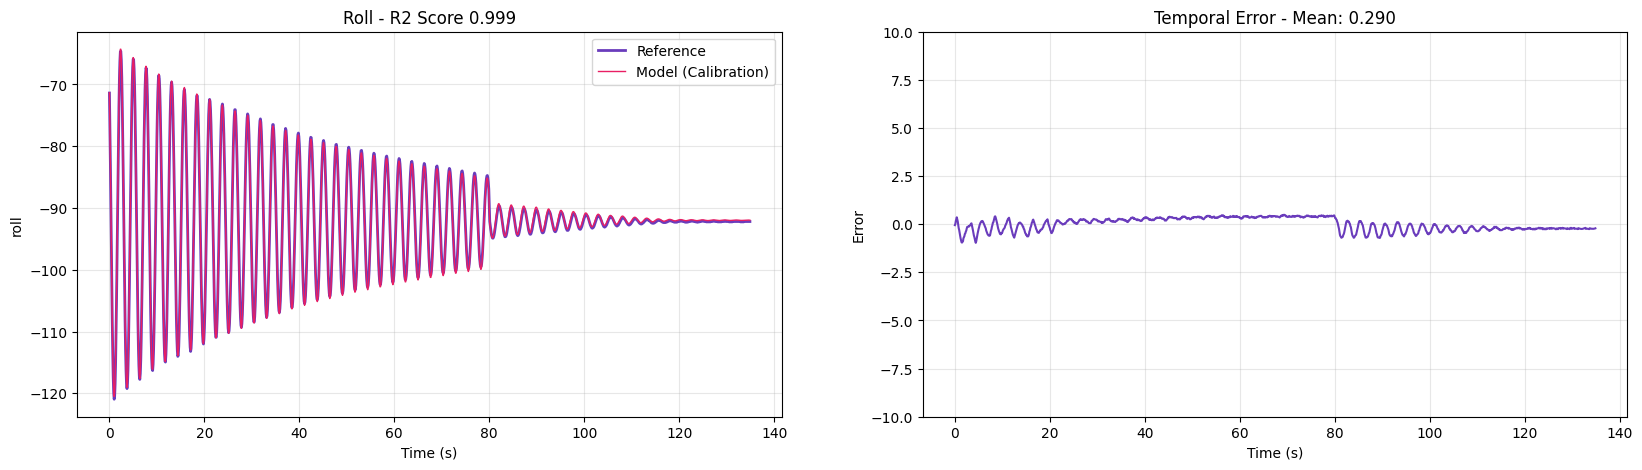

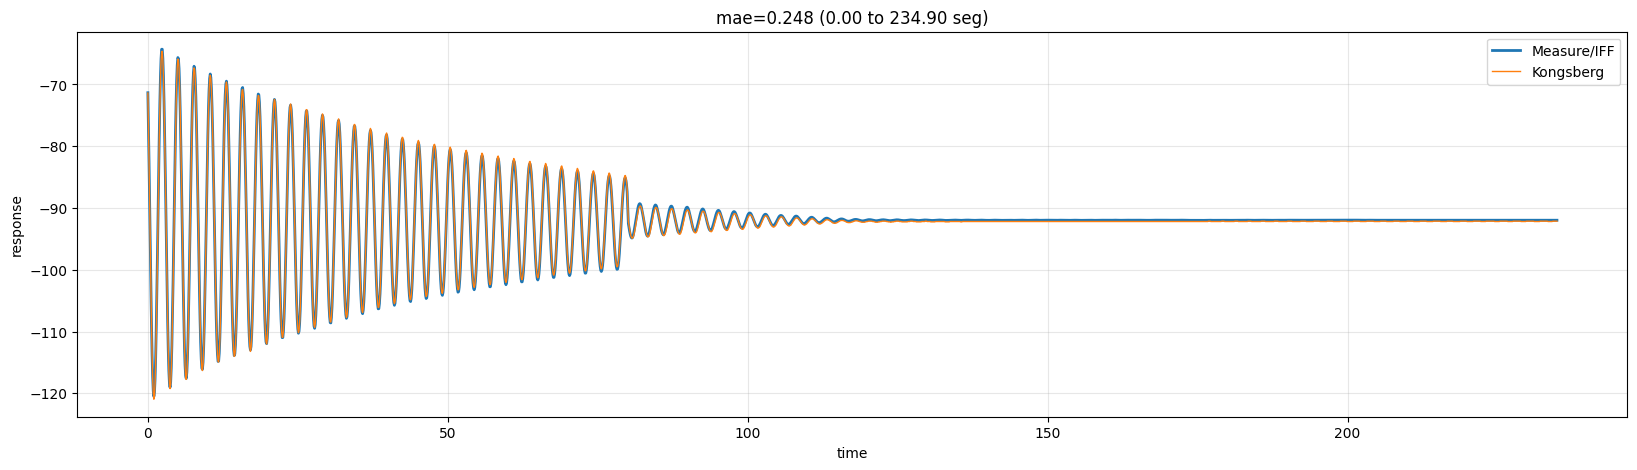

Dinamic Tests (roll)


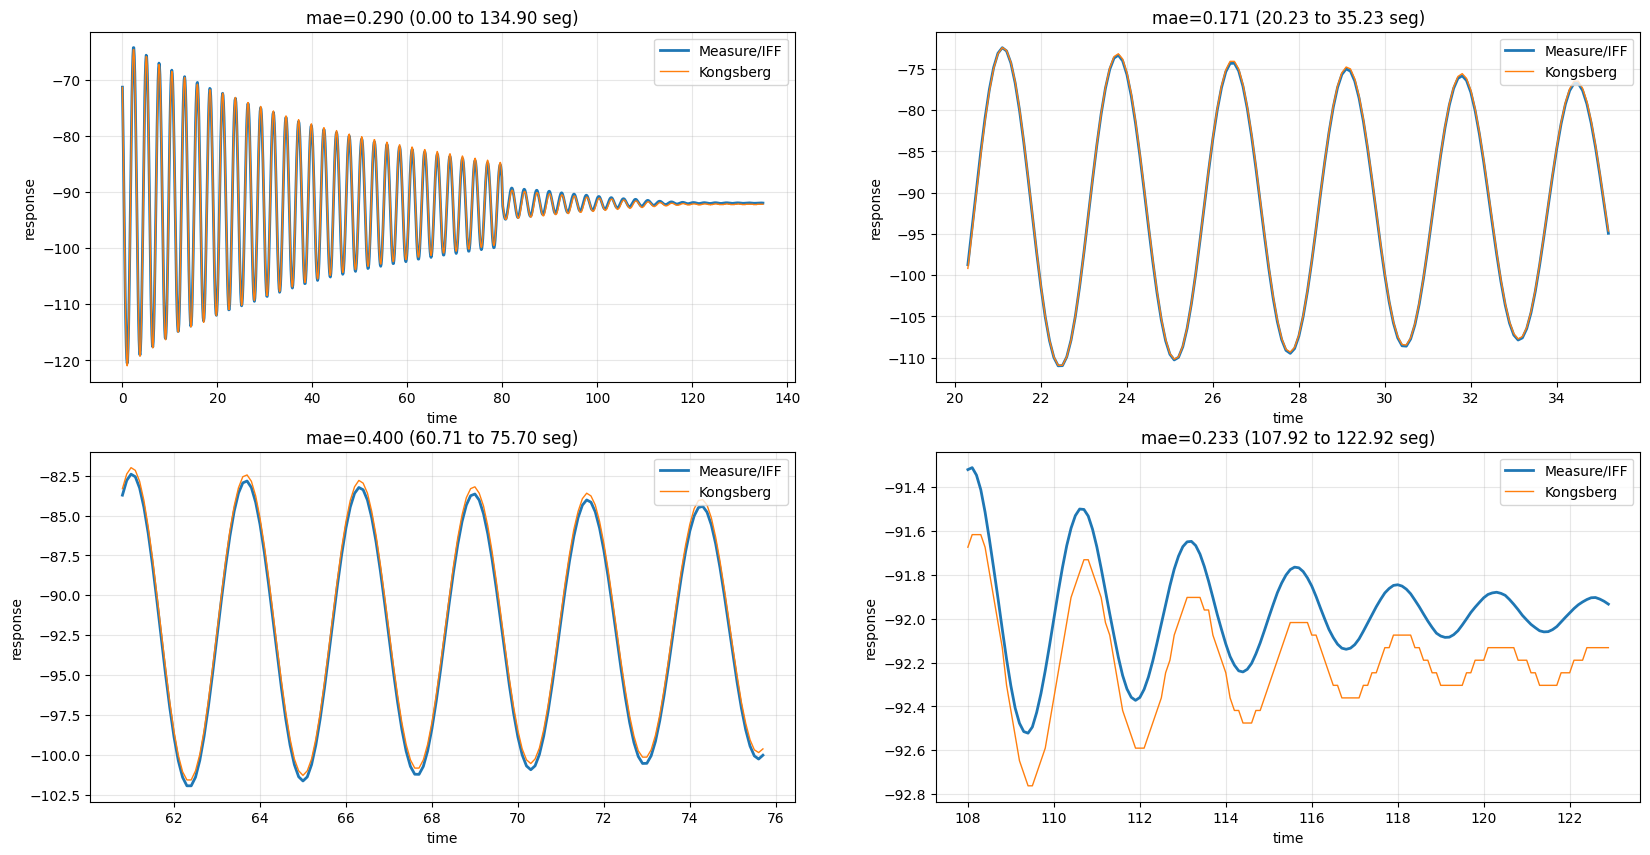

Static Tests (roll)


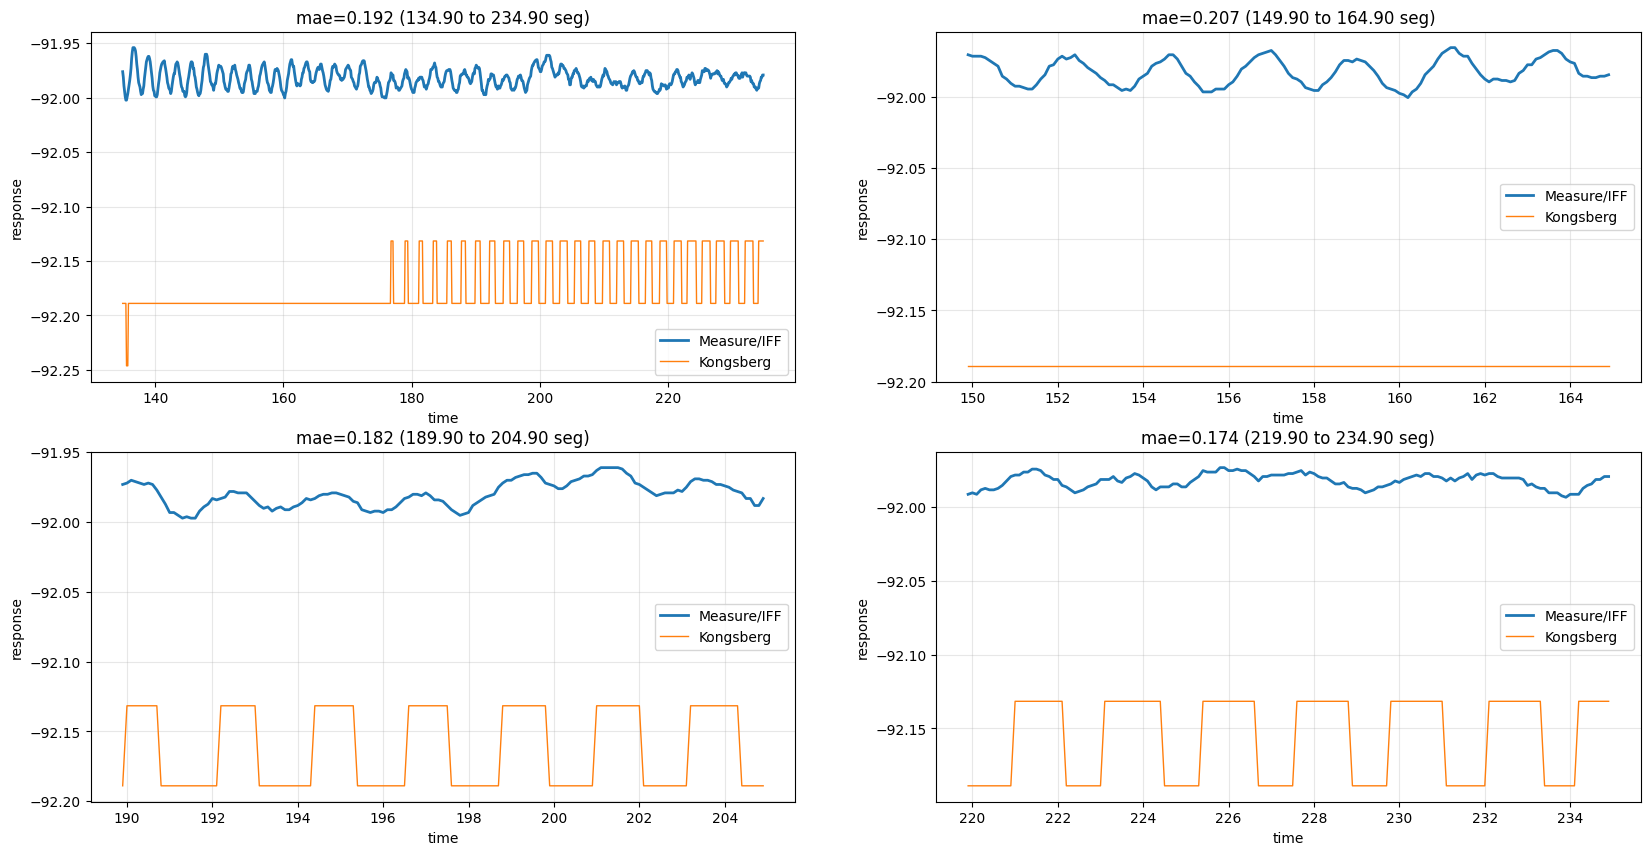

,wx,wy,wz,bias
wx_model,1.002654,0.000000,0.000000,0.004998
wy_model,0.000000,-0.358893,0.000000,-0.007029
wz_model,0.000000,0.000000,-0.072180,-0.000200


------------------------------------------------------------------------------------- WX -------------------------------------------------------------------------------------


,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
0,0.995765,0.940259,1.386431,0.447843,0.224759,0.223938,9185.540153,0.224364,-0.510312


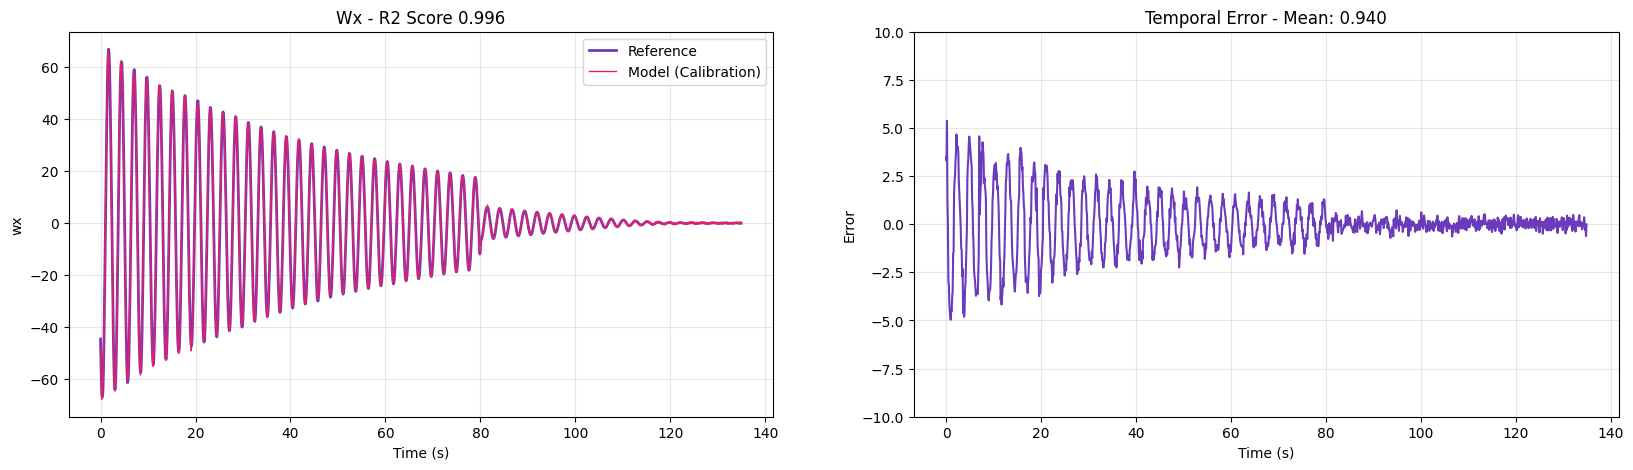

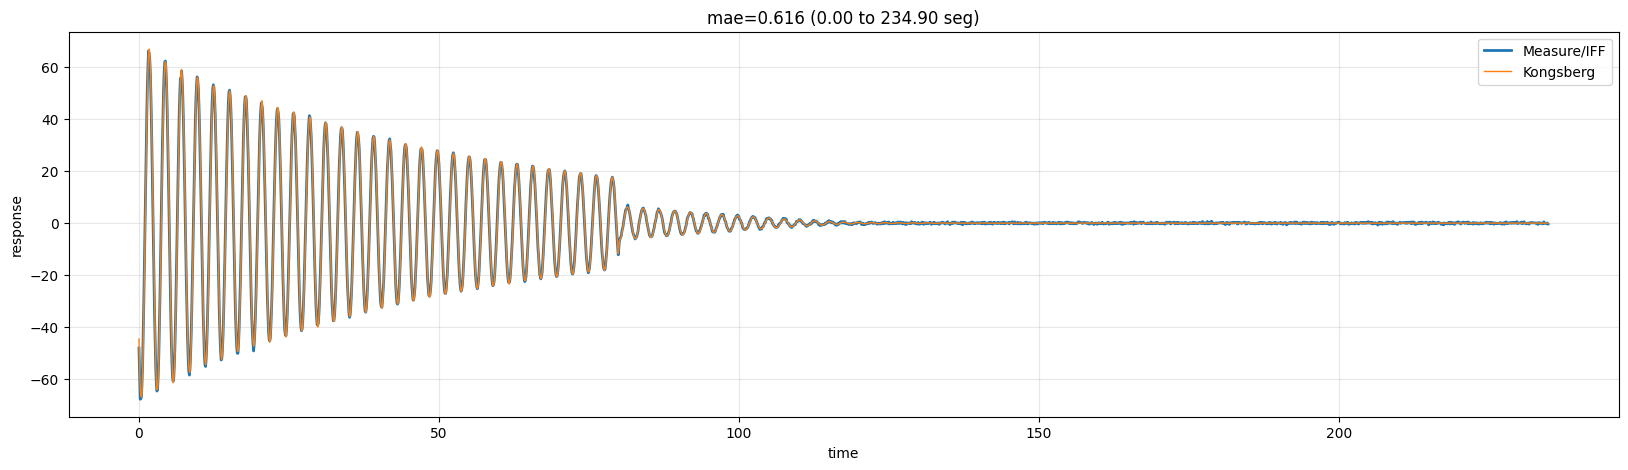

Dinamic Tests (wx)


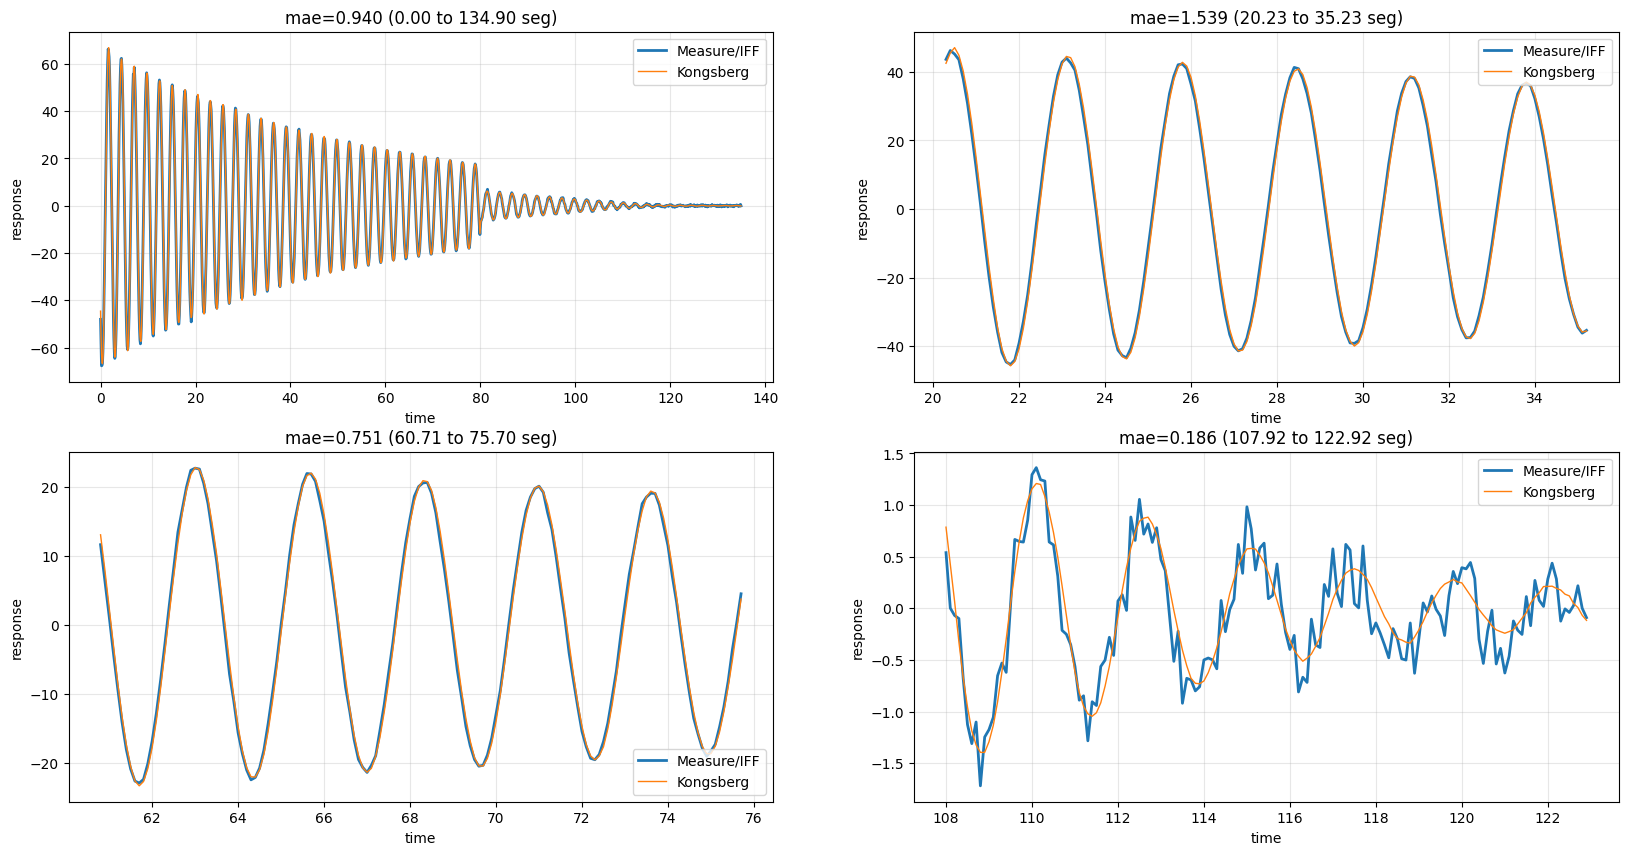

Static Tests (wx)


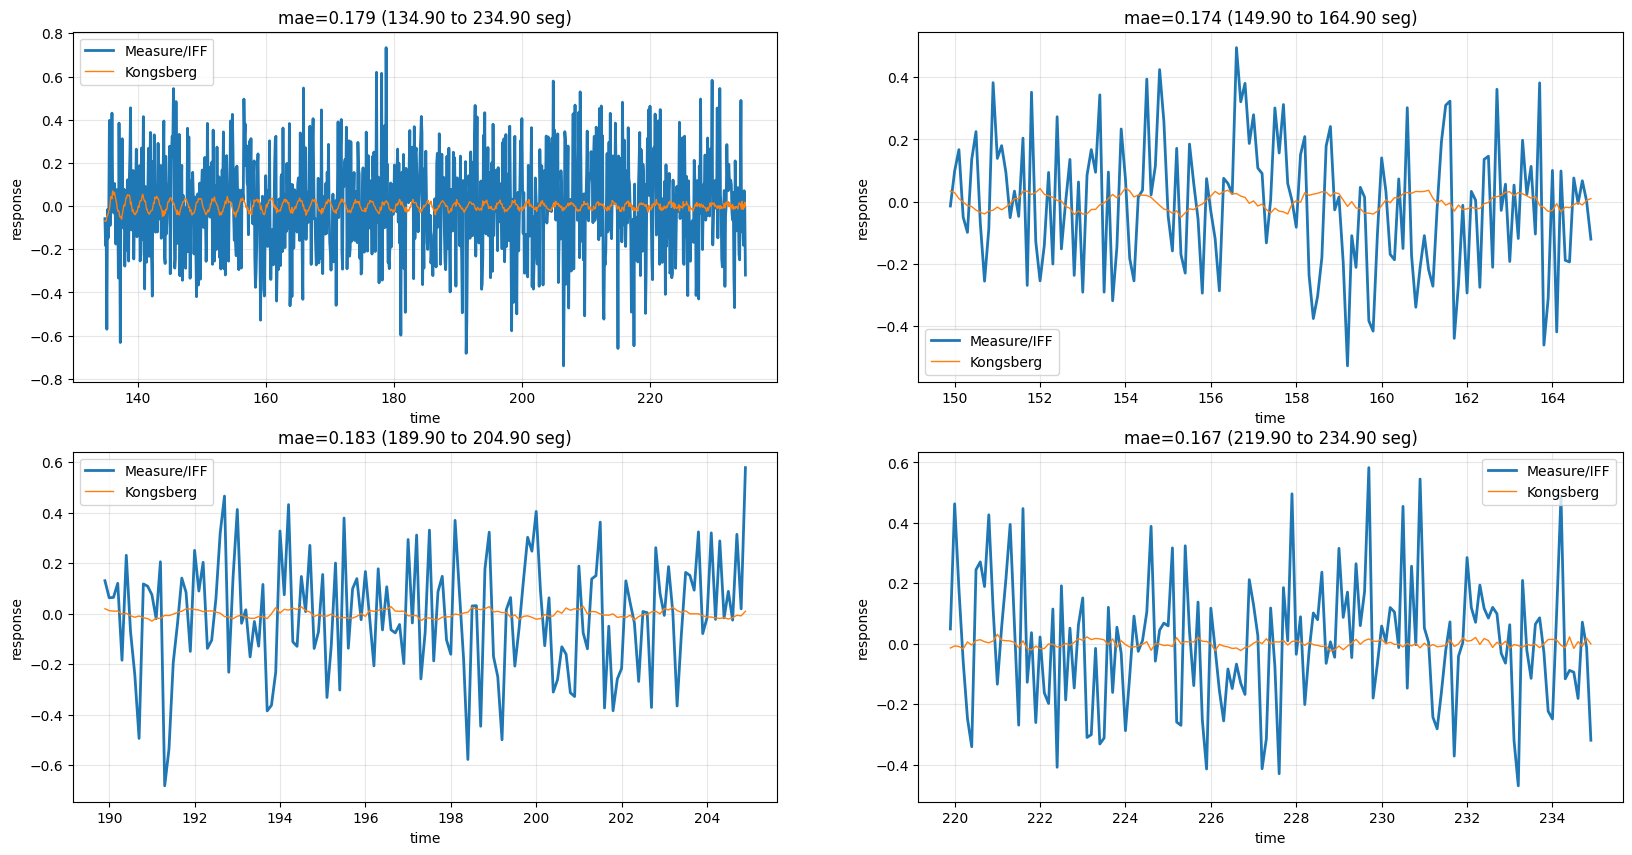

,ax,ay,az,bias
ax_model,0.063720,0.000000,0.000000,0.100750
ay_model,0.000000,0.826474,0.000000,1.727803
az_model,0.000000,0.000000,-0.846773,0.039822


------------------------------------------------------------------------------------- AZ -------------------------------------------------------------------------------------


,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
0,0.651632,0.07441,0.118437,0.033434,0.016787,0.038874,505.528913,0.016693,-0.098356


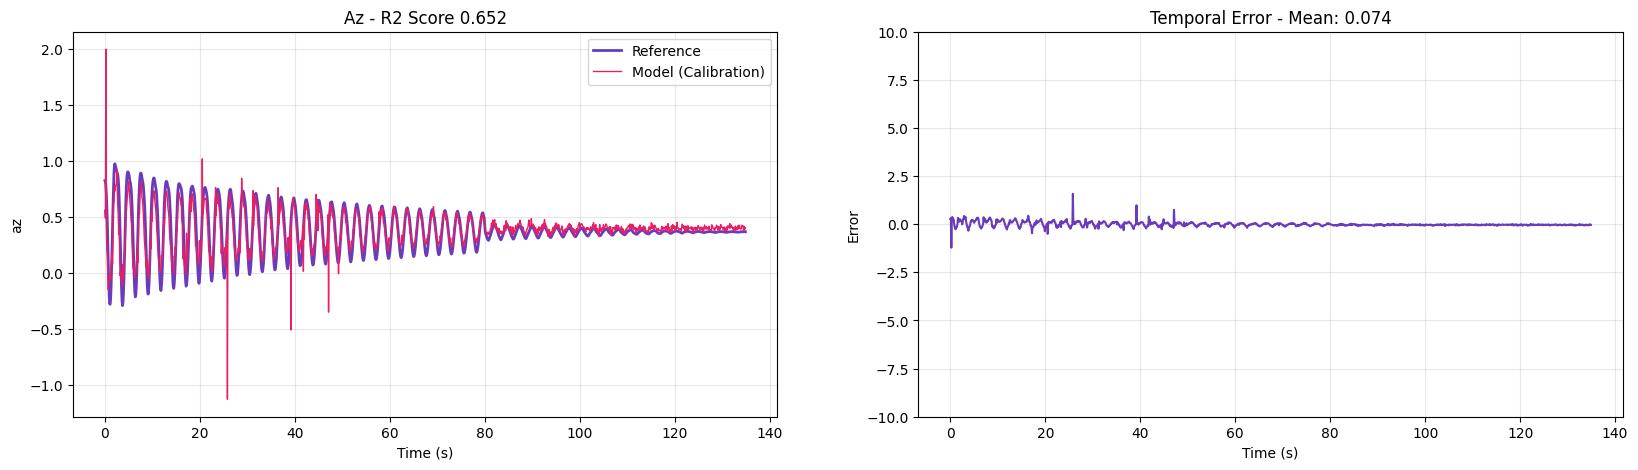

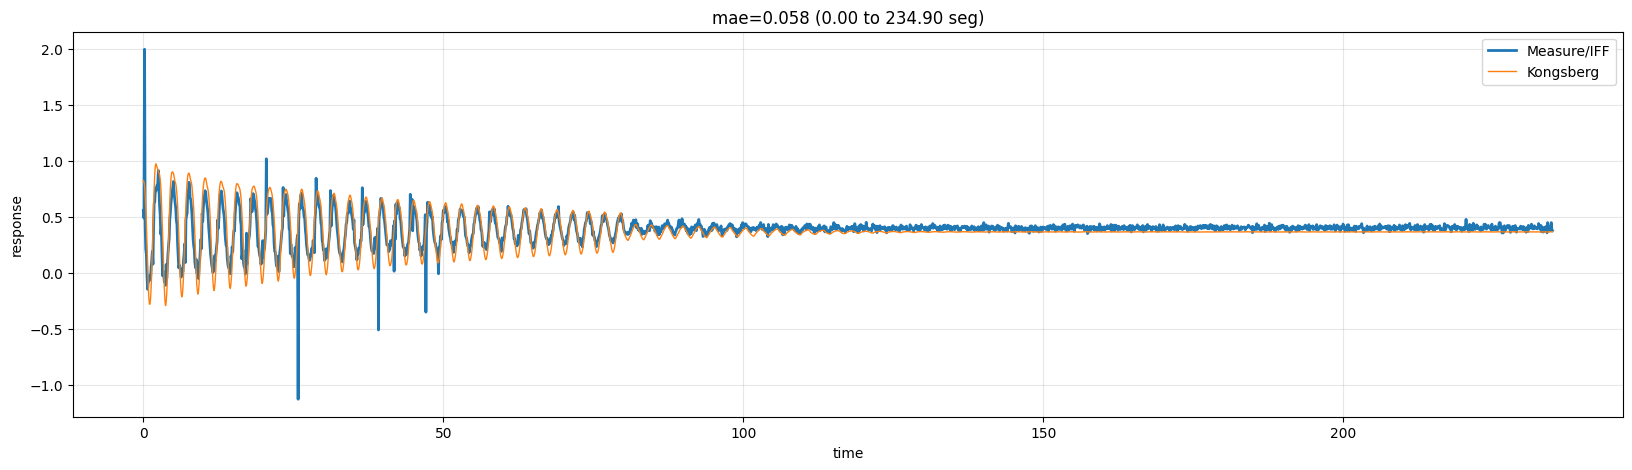

Dinamic Tests (az)


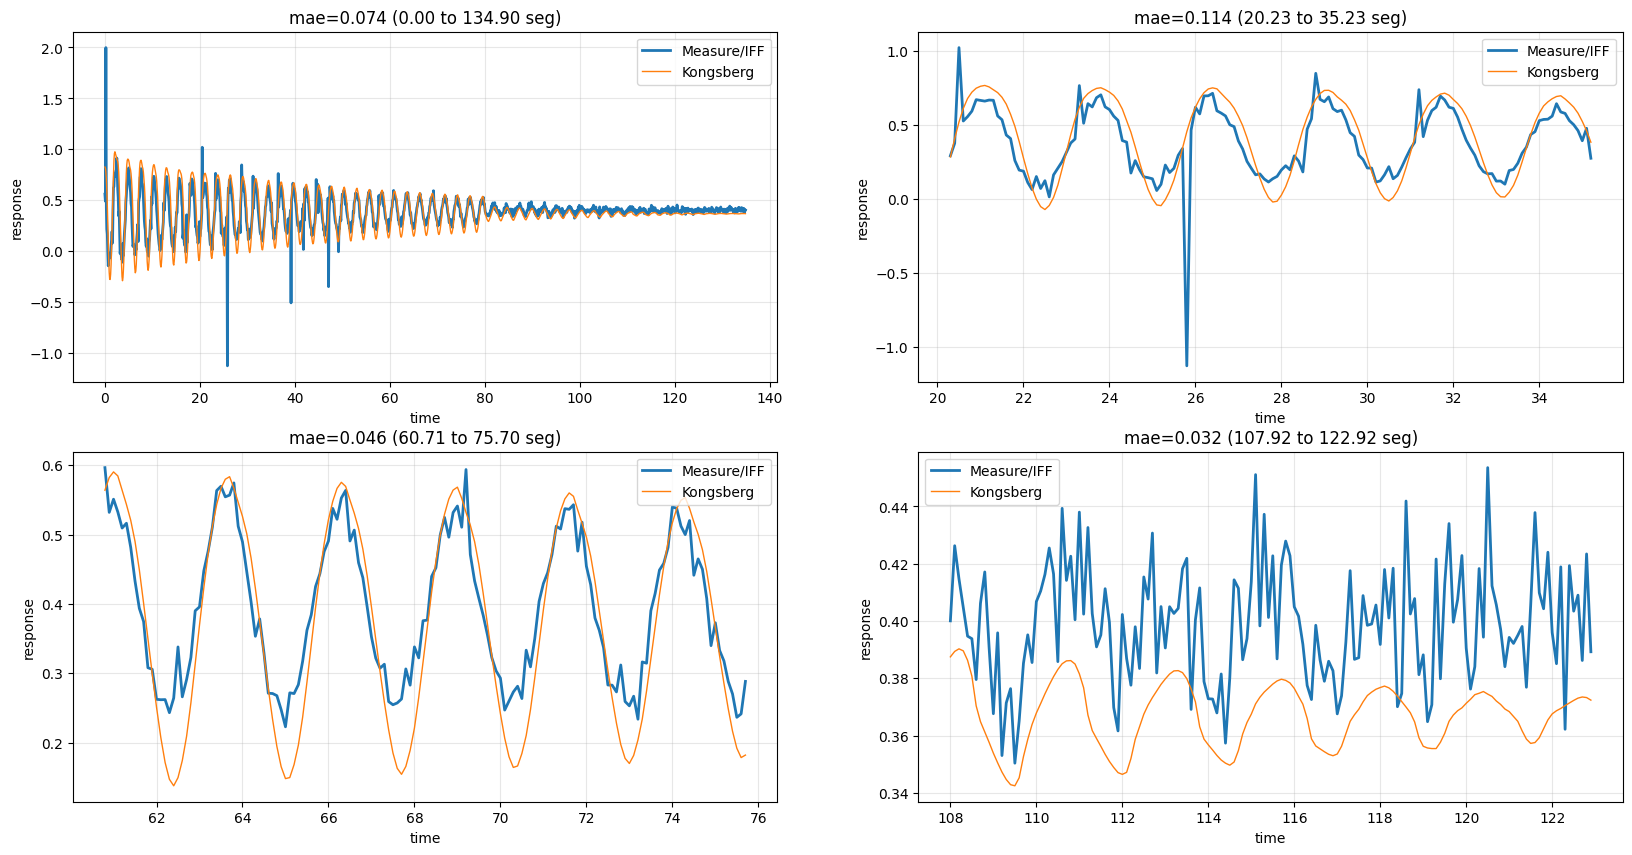

Static Tests (az)


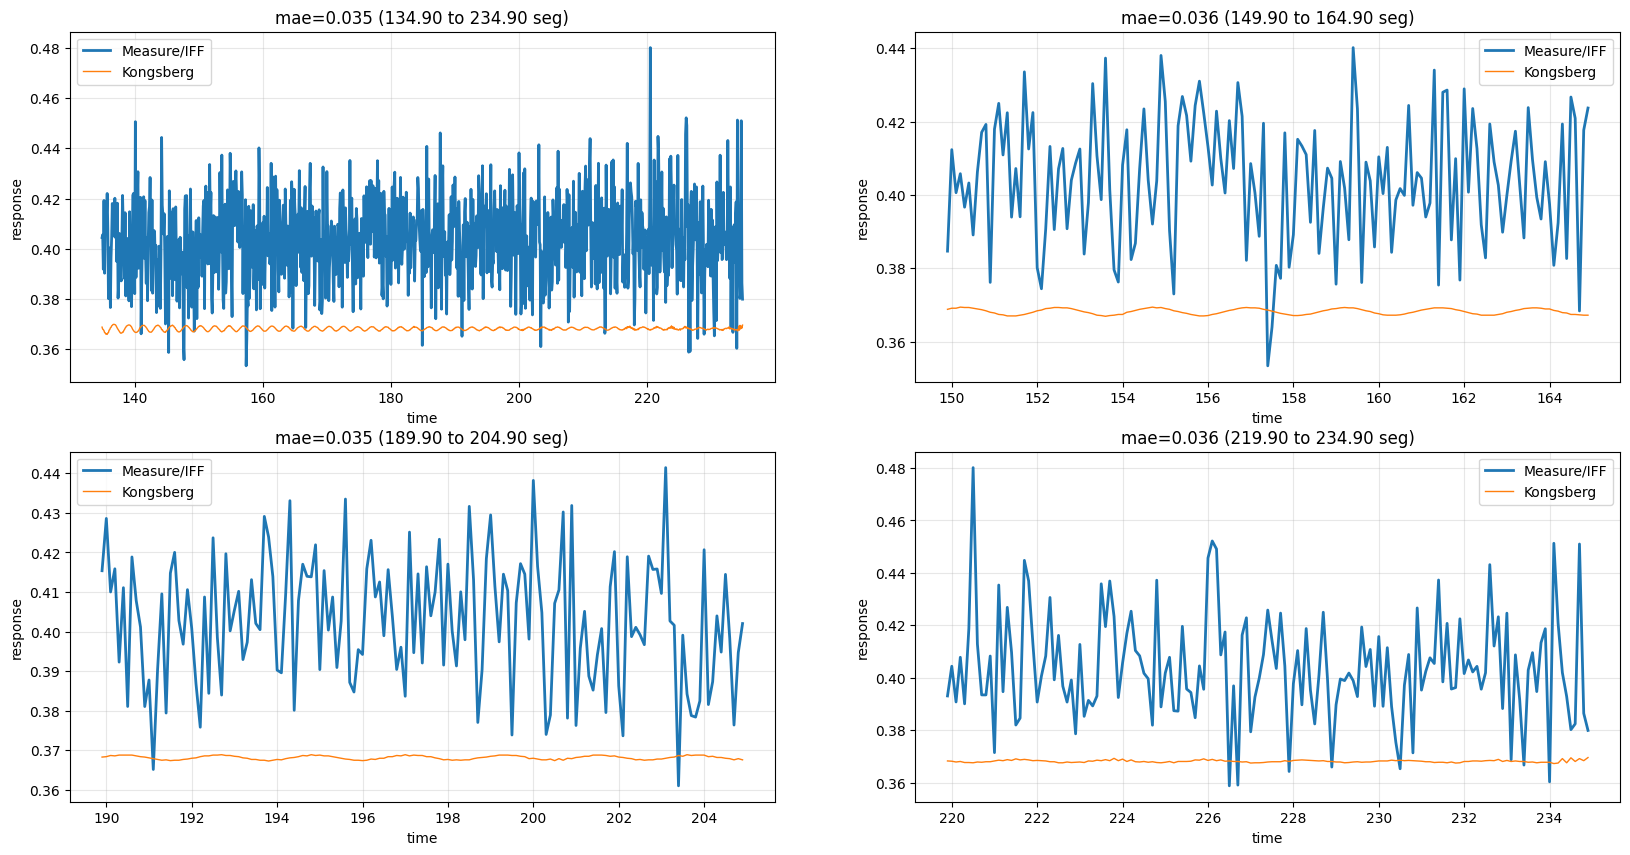

In [27]:
history = {}

for label, variables in groups.items():
    model = LinearFit(df_dynamic, variables, fuse=False)
    model.update()
    model.display()
    
    for idx, var in enumerate(variables):
        if var not in target_axis:
            continue

        df_dynamic['model_' + var] = model.predict(idx)
        df_static['model_'  + var] = df_static[[f'target_{v}' for v in variables]].values @ model.M[idx] + model.B[idx]
        
        print('-'*85, var.upper(), '-'*85)
        cal = CalibrationAnalysis(model, df_dynamic, df_static, var)
        cal.update()
        cal.display()

        model.plot(idx)
        plt.show()

        plt.figure(figsize=(20, 5))
        df_united = pd.concat([df_dynamic, df_static], axis=0)
        plotCurves(df_united, f'model_{var}', f'ref_{var}', limits=(0, 1))
        plt.show()
    
        model.metrics[var] = cal.metrics
        history[var]       = cal.metrics
                
        exporter = ResultExporter('Certificate', var, model)
        exporter.export()

        # ----------------------------- GRÁFICOS DE ZOOM ----------------------------- 
        print(f'Dinamic Tests ({var})')
        spacing = spacing_seconds/(df_dynamic.time.max() - df_dynamic.time.min())
        plt.figure(figsize=(20, 10))
        plt.subplot(2, 2, 1)
        plotCurves(df_dynamic, f'model_{var}', f'ref_{var}', limits=(0, 1))

        plt.subplot(2, 2, 2)
        plotCurves(df_dynamic, f'model_{var}', f'ref_{var}', limits=(0.15, 0.15+spacing))
        
        plt.subplot(2, 2, 3)
        plotCurves(df_dynamic, f'model_{var}', f'ref_{var}', limits=(0.45, 0.45+spacing))
        
        plt.subplot(2, 2, 4)
        plotCurves(df_dynamic, f'model_{var}', f'ref_{var}', limits=(0.8, 0.8+spacing))
        plt.show()

        print(f'Static Tests ({var})')
        spacing = spacing_seconds/(df_static.time.max() - df_static.time.min())
        plt.figure(figsize=(20, 10))
        plt.subplot(2, 2, 1)
        plotCurves(df_static, f'model_{var}', f'ref_{var}', limits=(0, 1), norm=False)

        plt.subplot(2, 2, 2)
        plotCurves(df_static, f'model_{var}', f'ref_{var}', limits=(0.15, 0.15+spacing), norm=False)

        plt.subplot(2, 2, 3)
        plotCurves(df_static, f'model_{var}', f'ref_{var}', limits=(0.55, 0.55+spacing), norm=False)

        plt.subplot(2, 2, 4)
        plotCurves(df_static, f'model_{var}', f'ref_{var}', limits=(0.85, 0.85+spacing), norm=False)
        plt.show()

In [28]:
pd.DataFrame(history).T.drop(columns=['correctionMatrixRow'])

,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
roll,0.998667,0.289528,0.328432,0.049658,0.009139,0.193158,0.361937,0.008645,1.720375
wx,0.995765,0.940259,1.386431,0.447843,0.224759,0.223938,9185.540153,0.224364,-0.510312
az,0.651632,0.07441,0.118437,0.033434,0.016787,0.038874,505.528913,0.016693,-0.098356
